In [191]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import numpy as np

In [192]:
dataset = load_diabetes()

In [193]:
X = dataset.data[:, 2].reshape(-1, 1)  # Use only the first two features for simplicity
y = dataset.target.reshape(-1, 1)
# Reshaping is must it prevents subtracting every row with every target variable values.

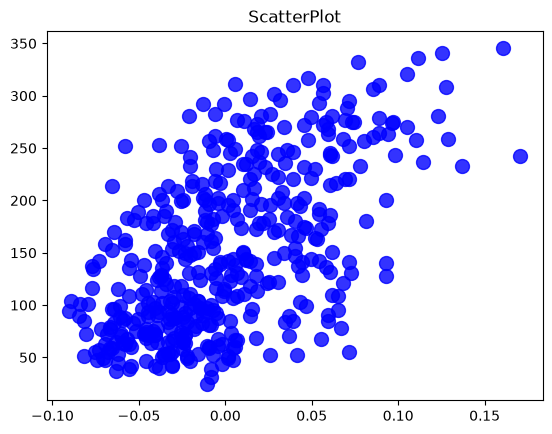

In [194]:
# Plotting X and Y
plt.scatter(X, y, color='blue', marker='o', s=100, alpha=0.8)

plt.title("ScatterPlot")

plt.show()

In [195]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [196]:
X_train.shape

(353, 1)

In [197]:
LR = LinearRegression()
LR.fit(X_train, y_train)
print("y = mx + b")
print(f"m = {LR.coef_}")
print(f"b = {LR.intercept_}")

y = mx + b
m = [[998.57768914]]
b = [152.00335421]


In [198]:
y_pred = LR.predict(X_test)
RS2 = r2_score(y_test, y_pred)
print(f"R-squared Score: {RS2}")

R-squared Score: 0.23335039815872138


In [199]:
class APNAGD_LinearRegression:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.coeff_ = 0
        self.intercept_ = 0

    def fit(self, X_train, y_train):
        # Intialize with random values for coeff_ and intercept_
        self.coeff_ = 0.0
        self.intercept_ = 0.0
        n = len(X_train)

        for i in range(self.epochs):
            y_pred = self.predict(X_train)
            error = y_pred - y_train
            
            derivative_coef = (2/n) * np.sum(error * X_train)
            derivative_intercept = (2/n) * np.sum(error)

            self.coeff_ -= self.learning_rate * derivative_coef
            self.intercept_ -= self.learning_rate * derivative_intercept

    def predict(self, X_test):
        return (self.coeff_ * X_test) + self.intercept_

In [200]:
GDLR = APNAGD_LinearRegression(learning_rate=0.2, epochs=10000)
GDLR.fit(X_train, y_train)
y_pred_GDLR = GDLR.predict(X_test)
r2_score_GDLR = r2_score(y_test, y_pred_GDLR)

In [201]:
print(f"GLDR R-squared Score: {r2_score_GDLR}")
print(f"GDLR Coefficient: ", GDLR.coeff_)
print(f"GLDR Intercept: ", GDLR.intercept_)
print("----")
print(f"R-squared Score: {RS2}")
print(f"m = {LR.coef_}")
print(f"b = {LR.intercept_}")

GLDR R-squared Score: 0.2333783087700032
GDLR Coefficient:  998.4440171666902
GLDR Intercept:  152.00358674156584
----
R-squared Score: 0.23335039815872138
m = [[998.57768914]]
b = [152.00335421]


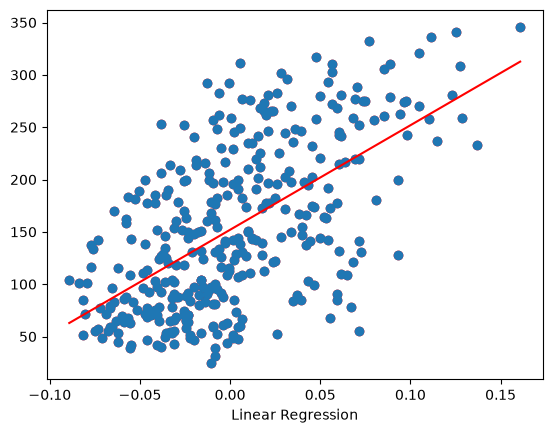

In [207]:
plt.scatter(X_train, y_train, color='red', label='Data')

x_line = np.linspace(X_train.min(), X_train.max(), 100)
y_line = LR.coef_[0][0] * x_line + LR.intercept_[0]

plt.scatter(X_train, y_train)
plt.plot(x_line, y_line, color='red')
plt.xlabel("Linear Regression")
plt.show()

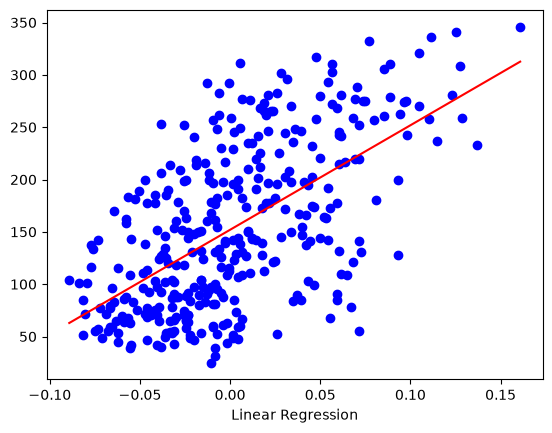

In [211]:
plt.scatter(X_train, y_train, color='blue', label='Data')

x_line_GDLR = np.linspace(X_train.min(), X_train.max(), 100)
y_line_GDLR = GDLR.coeff_ * x_line + GDLR.intercept_
plt.plot(x_line_GDLR, y_line_GDLR, color='red')
plt.xlabel("Linear Regression")
plt.show()